# Mandatory Assignment 02, Part 2, Question 2

## Names and Student id's:

Clara Stenbo Nielsen, 185942

Henrik Brøgger Forsbak Langfeldt, 185884

Lucia Victoria Robertsen-Molina, 185914

Axel Gustaf Edward Lidvall, 185892

## 1 Data Preperation


### 1.1 Loading the data

#### Importing libraries

In [71]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/henriklangfeldt/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/henriklangfeldt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Making the dataframe

In [72]:
df = pd.read_csv('CyberBullying Comments Dataset.csv')
df.head()

,Text,CB_Label
0,damn there is someones nana up here at beach w...,0
1,no kidding! dick clark was a corpse mechanical...,0
2,i read an article on jobros and thought damn w...,0
3,I got one fucking day of sprinkles and now it'...,0
4,I was already listening to Elliott smith and ...,0


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11100 entries, 0 to 11099
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Text      11100 non-null  str  
 1   CB_Label  11100 non-null  int64
dtypes: int64(1), str(1)
memory usage: 173.6 KB


### 1.2 Data Exploration (EDA)

Before building any model, we need to understand the data. We check for:
- **Class distribution**: if one class is much larger than the other, the dataset is imbalanced, which can cause the model to be biased toward the majority class.
- **Missing values**: any missing tweet text or labels would need to be handled before training.

In [74]:
# Check class distribution
print('Class distribution:')
print(df['CB_Label'].value_counts())
print()

# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Class distribution:
CB_Label
0    5550
1    5550
Name: count, dtype: int64

Missing values per column:
Text        0
CB_Label    0
dtype: int64


### 1.3 Text Preprocessing

Raw tweet text contains a lot of noise (uppercase letters, stopwords like "the" and "is", word variants like "running" vs "run"). We clean the text so the model focuses on meaningful content.

The preprocessing function applies four steps:
1. **Lowercase**: ensures "Hate" and "hate" are treated as the same word.
2. **Tokenization**: splits the text into individual word tokens, which is required before any further processing.
3. **Stopword removal**: removes common English words ("the", "is", "and") that carry no signal for detecting cyberbullying.
4. **Stemming** (PorterStemmer): reduces words to their root form ("bullying" and "bullied" both become "bulli"), reducing the vocabulary size and helping the model generalize.

This answers the assignment requirement to "preprocess the text data (tokenize, lowercase, remove stop words etc.)".

In [75]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    # Step 1: lowercase
    text = text.lower()
    # Step 2: tokenize
    tokens = word_tokenize(text)
    # Step 3 and 4: remove stopwords and stem
    cleaned = [ps.stem(t) for t in tokens if t not in stop_words and t.isalpha()]
    return ' '.join(cleaned)

df['cleaned_tweet'] = df['Text'].apply(preprocess)

# Preview the result
print(df[['Text', 'cleaned_tweet']].head(5))

                                                Text  \
0  damn there is someones nana up here at beach w...   
1  no kidding! dick clark was a corpse mechanical...   
2  i read an article on jobros and thought damn w...   
3  I got one fucking day of sprinkles and now it'...   
4  I was already listening to Elliott smith  and ...   

                                       cleaned_tweet  
0  damn someon nana beach one dont think ic steal...  
1  kid dick clark corps mechan oper advertis compani  
2  read articl jobro thought damn cash jobro poke...  
3  got one fuck day sprinkl back sunshin doucheba...  
4  alreadi listen elliott smith fuck hate kany we...  


### 1.4 Train/Test Split

We split the data into 80% training and 20% testing, as required by the assignment. The training set is used to fit the model, and the test set is held out to evaluate performance on unseen data.

We set `random_state=42` to make the split reproducible. Importantly, the split is done **before** vectorization, so the vectorizer can be fit only on training data, preventing data leakage from the test set into the model.

In [ ]:
X = df['cleaned_tweet']
y = df['CB_Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1337)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 8880
Testing samples:  2220


### 1.5 Feature Extraction (Bag of Words Vectorization)

Machine learning models are mathematical functions that operate on numbers. Raw tweet text like `"you are so ugly"` cannot be passed directly into a classifier. Vectorization converts each tweet into a numerical vector that the model can process.


We chose BoW because:
- It is straightforward and interpretable, each feature is a word count.
- It pairs naturally with Multinomial Naive Bayes, which models word count frequencies.

We fit the vectorizer **only on the training set**, then transform both train and test sets. This ensures the vocabulary is built without any knowledge of the test data, which is required for a valid evaluation.

In [77]:
vectorizer = CountVectorizer()

# Fit on training data only, then transform both sets
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')
print(f'Training matrix shape: {X_train_vec.shape}')
print(f'Test matrix shape:     {X_test_vec.shape}')

Vocabulary size: 10889
Training matrix shape: (8880, 10889)
Test matrix shape:     (2220, 10889)


## 2 Naive Bayes Classification

### 2.1 Making the Naive Bayes model

Naive Bayes is a probabilistic classifier based on Bayes' theorem. It calculates the probability that a tweet belongs to each class given the words it contains, and predicts the class with the highest probability.

The "naive" assumption is that each word is independent of all other words given the class. This is not true in reality (words like "you" and "ugly" tend to co-occur in cyberbullying), but the simplification works well in practice for text classification.

We use `MultinomialNB` from sklearn, which is designed for count-based features. It models the frequency of each word within each class, making it a natural fit for Bag of Words vectors where each value is a word count.

This answers the assignment requirement: "train Naive Bayes classifier".

In [78]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

y_pred_nb = nb.predict(X_test_vec)

### 2.2 Evaluate Naive Bayes

We evaluate the model using four metrics:

- **Accuracy**: the share of all tweets classified correctly. Useful as a general overview, but can be misleading if classes are imbalanced.
- **Precision**: of all tweets predicted as cyberbullying, how many actually were. High precision means few false alarms.
- **Recall**: of all actual cyberbullying tweets, how many did the model catch. High recall means few missed cases.
- **F1-score**: the harmonic mean of precision and recall, balancing both concerns. This is especially useful when the cost of missing a cyberbullying tweet (false negative) differs from the cost of a false alarm (false positive).

For cyberbullying detection, recall is particularly important: missing a genuine case of cyberbullying has real consequences, so we want the model to catch as many as possible.

This answers the assignment requirement: "report accuracy, precision, recall and F1-score".

Naive Bayes Accuracy: 0.7144

                   precision    recall  f1-score   support

Not Cyberbullying       0.71      0.74      0.73      1128
    Cyberbullying       0.72      0.68      0.70      1092

         accuracy                           0.71      2220
        macro avg       0.71      0.71      0.71      2220
     weighted avg       0.71      0.71      0.71      2220



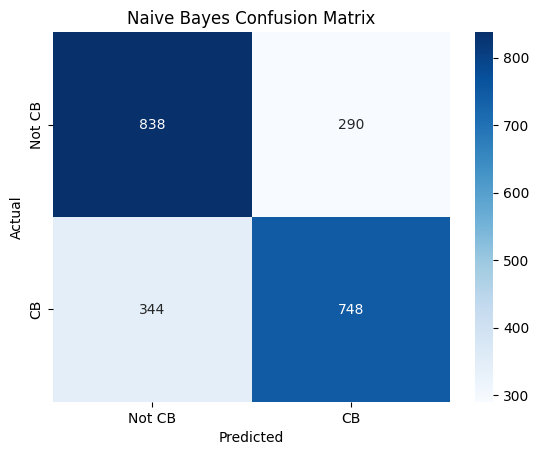

In [79]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print('Naive Bayes Accuracy:', round(accuracy_score(y_test, y_pred_nb), 4))
print()
print(classification_report(y_test, y_pred_nb, target_names=['Not Cyberbullying', 'Cyberbullying']))

cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Not CB', 'CB'],
            yticklabels=['Not CB', 'CB'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

## 3 Logistic Regression Classification

### 3.1 Making the Logistic Regression model

Logistic Regression is a linear classifier that models the probability of a tweet belonging to each class. Unlike Naive Bayes, it does not assume word independence. Instead, it learns a weight for each word in the vocabulary, where a positive weight pushes toward cyberbullying and a negative weight pushes toward not cyberbullying. The final prediction is based on the sum of all weighted word counts in the tweet.

We use `LogisticRegression(max_iter=1000)` from sklearn, following the pattern from Lab 5. The `max_iter=1000` parameter gives the solver enough iterations to converge on a dataset of this size, as the default of 100 can be insufficient for high-dimensional text data.

We train on the same `X_train_vec` and evaluate on the same `X_test_vec` as Naive Bayes, so the comparison between the two models is fair.

This answers the assignment requirement: "train Logistic Regression classifier".

In [80]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_vec, y_train)

y_pred_lr = lr.predict(X_test_vec)

### 3.2 Evaluate Logistic Regression

We evaluate Logistic Regression using the same metrics as Naive Bayes, allowing a direct comparison between the two models on identical train and test sets.

This answers the assignment requirement: "report accuracy, precision, recall and F1-score".

Logistic Regression Accuracy: 0.7185

                   precision    recall  f1-score   support

Not Cyberbullying       0.70      0.77      0.74      1128
    Cyberbullying       0.74      0.66      0.70      1092

         accuracy                           0.72      2220
        macro avg       0.72      0.72      0.72      2220
     weighted avg       0.72      0.72      0.72      2220



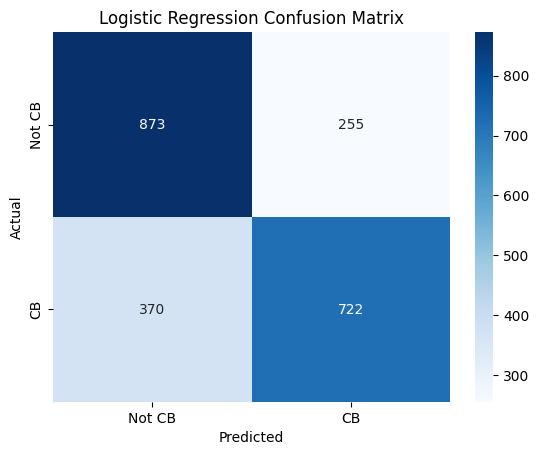

In [81]:
print('Logistic Regression Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))
print()
print(classification_report(y_test, y_pred_lr, target_names=['Not Cyberbullying', 'Cyberbullying']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d',
            xticklabels=['Not CB', 'CB'],
            yticklabels=['Not CB', 'CB'],
            cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

## 4 Comparison and Conclusion

### 4.1 Performance Comparison

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.7144 | 0.7185 |
| Precision (CB) | 0.72 | 0.74 |
| Recall (CB) | 0.68 | 0.66 |
| F1-score (CB) | 0.70 | 0.70 |

### 4.2 Discussion

**Which model performs better?**

The two models perform very similarly overall. Logistic Regression achieves marginally higher accuracy (71.85% vs 71.44%) and higher precision on the cyberbullying class (0.74 vs 0.72), meaning it produces fewer false alarms. However, Naive Bayes achieves higher recall on the cyberbullying class (0.68 vs 0.66), meaning it catches more actual cyberbullying cases. The F1-score is identical for both models (0.70) (atleast with only 2 desimals). 

**Naive Bayes**

Advantages for this task:
- Very fast to train, even on a vocabulary of ~10,000 words, because it only needs to count word frequencies per class rather than optimize a set of weights.
- Works well with small datasets since it does not require many examples to estimate probabilities reliably.
- Achieves higher recall on the cyberbullying class (0.68 vs 0.66), catching more genuine cases. But this is only a marginal difference

Disadvantages for this task:
- The independence assumption is violated in practice. Words in cyberbullying tweets frequently co-occur (e.g., "you" and "ugly"), and Naive Bayes cannot capture these relationships.
- Lower precision than Logistic Regression (0.72 vs 0.74), meaning it produces slightly more false alarms. But this is also only a marginal difference

**Logistic Regression**

Advantages for this task:
- Does not assume word independence. It learns a weight for each word in context of all other words, allowing it to find more nuanced patterns.
- Higher precision on the cyberbullying class (0.74 vs 0.72), meaning fewer innocent tweets are incorrectly flagged.
- **Slightly** higher overall accuracy (71.85% vs 71.44%). 

Disadvantages for this task:
- Slower to train than Naive Bayes, as it requires iterative optimization over the full feature space.
- Lower recall on the cyberbullying class (0.66 vs 0.68), meaning it misses more genuine cyberbullying cases.

**Class balance**

The dataset is perfectly balanced (5,550 cyberbullying and 5,550 not cyberbullying), which means accuracy is a reliable metric and neither model is biased toward a majority class. This also means the macro and weighted averages in the classification reports are identical.

### 4.3 Conclusion

Both models achieve similar performance on this task, with accuracy around 71% and an F1-score of 0.70 for the cyberbullying class. The marginal differences suggest that the independence assumption in Naive Bayes is not a significant disadvantage here, likely because individual words ("hate", "ugly", "kill") are already strong predictors of cyberbullying on their own. For a real-world system where catching cyberbullying cases matters more than avoiding false alarms, Naive Bayes is the preferred model due to its higher recall. If minimising false alarms is the priority, Logistic Regression is the better choice. But these differences are very marginal.